In [27]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score

Installing Pandas-TA Library

In [28]:
!pip install pandas_ta TA-Lib

In [29]:
import yfinance as yf
import pandas_ta as ta

Downloading the IVV data

In [30]:
TICKER = "IVV"
START = "2009-01-01"
END = "2020-01-01"

In [31]:
df = yf.download(TICKER, start=START, end=END, auto_adjust=False)
df.head(5)

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,IVV,IVV,IVV,IVV,IVV,IVV
Date,,,,,,
2009-01-02,68.294334,93.260002,93.660004,90.099998,90.750000,3876800
2009-01-05,68.118599,93.019997,93.839996,92.080002,92.830002,6354200
2009-01-06,68.550636,93.610001,94.650002,92.900002,93.919998,6392600
2009-01-07,66.536858,90.860001,92.470001,90.419998,92.110001,4366100
2009-01-08,66.829735,91.260002,91.260002,89.879997,90.339996,3967600


In [32]:
df.columns = [col[0] for col in df.columns]

In [33]:
df

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2009-01-02,68.294334,93.260002,93.660004,90.099998,90.750000,3876800
2009-01-05,68.118599,93.019997,93.839996,92.080002,92.830002,6354200
2009-01-06,68.550636,93.610001,94.650002,92.900002,93.919998,6392600
2009-01-07,66.536858,90.860001,92.470001,90.419998,92.110001,4366100
2009-01-08,66.829735,91.260002,91.260002,89.879997,90.339996,3967600
...,...,...,...,...,...,...
2019-12-24,294.688629,322.649994,322.929993,322.309998,322.869995,2716300
2019-12-26,296.213989,324.320007,324.329987,323.019989,323.059998,2847400
2019-12-27,296.159149,324.260010,325.190002,323.709991,325.190002,5091400


In [34]:
#copy the main df incase of error in change
feat_df = df.copy()

In [35]:
feat_df.head()

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2009-01-02,68.294334,93.260002,93.660004,90.099998,90.750000,3876800
2009-01-05,68.118599,93.019997,93.839996,92.080002,92.830002,6354200
2009-01-06,68.550636,93.610001,94.650002,92.900002,93.919998,6392600
2009-01-07,66.536858,90.860001,92.470001,90.419998,92.110001,4366100
2009-01-08,66.829735,91.260002,91.260002,89.879997,90.339996,3967600


Feature Extraction

In [36]:
print(feat_df.ta.indicators())

Pandas TA - Technical Analysis Indicators - v0.4.71b0

Indicators and Utilities [154]:
    aberration, accbands, ad, adosc, adx, alligator, alma, alphatrend, amat, ao, aobv, apo, aroon, atr, atrts, bbands, bias, bop, brar, cci, cdl_pattern, cdl_z, cfo, cg, chandelier_exit, chop, cksp, cmf, cmo, coppock, crsi, cti, decay, decreasing, dema, dm, donchian, dpo, ebsw, efi, ema, entropy, eom, er, eri, exhc, fisher, fwma, ha, hilo, hl2, hlc3, hma, ht_trendline, hwc, hwma, ichimoku, increasing, inertia, jma, kama, kc, kdj, kst, kurtosis, kvo, linreg, log_return, long_run, macd, mad, mama, massi, mcgd, median, mfi, midpoint, midprice, mom, natr, nvi, obv, ohlc4, pdist, percent_return, pgo, pivots, ppo, psar, psl, pvi, pvo, pvol, pvr, pvt, pwma, qqe, qstick, quantile, reflex, rma, roc, rsi, rsx, rvgi, rvi, rwi, short_run, sinwma, skew, slope, sma, smc, smi, smma, squeeze, squeeze_pro, ssf, ssf3, stc, stdev, stoch, stochf, stochrsi, supertrend, swma, t3, tema, thermo, tmo, tos_stdevall, trendflex

In [37]:
# Get indicator names
inds = feat_df.ta.indicators(as_list=True)  # list of strings

# Apply each indicator (some will fail because they need special args; we skip errors)
for name in inds:
    try:
        feat_df.ta(kind=name, append=True)
    except Exception:
        pass

# feat_df = feat_df.dropna(axis=1, how="all")
# feat_df = feat_df.dropna()

In [38]:
feat_df

,Adj Close,Close,High,Low,Open,Volume,ABER_ZG_5_15,ABER_SG_5_15,ABER_XG_5_15,ABER_ATR_5_15,...,VWAP_D,VWMA_10,WCP,WILLR_14,WMA_10,ZIGZAGs_5.0%_10,ZIGZAGv_5.0%_10,ZIGZAGd_5.0%_10,ZL_EMA_10,ZS_30
Date,,,,,,,,,,,,,,,,,,,,,
2009-01-02,68.294334,93.260002,93.660004,90.099998,90.750000,3876800,NaN,NaN,NaN,NaN,...,92.340001,NaN,92.570002,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2009-01-05,68.118599,93.019997,93.839996,92.080002,92.830002,6354200,NaN,NaN,NaN,NaN,...,92.979998,NaN,92.989998,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2009-01-06,68.550636,93.610001,94.650002,92.900002,93.919998,6392600,NaN,NaN,NaN,NaN,...,93.720001,NaN,93.692501,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2009-01-07,66.536858,90.860001,92.470001,90.419998,92.110001,4366100,NaN,NaN,NaN,NaN,...,91.250000,NaN,91.152500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2009-01-08,66.829735,91.260002,91.260002,89.879997,90.339996,3967600,92.218000,NaN,NaN,NaN,...,90.800001,NaN,90.915001,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-12-24,294.688629,322.649994,322.929993,322.309998,322.869995,2716300,321.547331,323.384465,319.710197,1.837134,...,322.629995,320.028711,322.634995,-6.363747,321.014723,NaN,NaN,NaN,322.710887,1.915205
2019-12-26,296.213989,324.320007,324.329987,323.019989,323.059998,2847400,322.405998,324.232656,320.579340,1.826658,...,323.889994,320.728789,323.997498,-0.102667,321.788543,NaN,NaN,NaN,323.654366,2.149361
2019-12-27,296.159149,324.260010,325.190002,323.709991,325.190002,5091400,323.223999,325.027547,321.420451,1.803548,...,324.386668,321.350678,324.355003,-8.790087,322.403273,NaN,NaN,NaN,324.106302,1.949792


Data Cleaning

In [39]:
feat_df = feat_df.loc["2009-12-12":]
feat_df

,Adj Close,Close,High,Low,Open,Volume,ABER_ZG_5_15,ABER_SG_5_15,ABER_XG_5_15,ABER_ATR_5_15,...,VWAP_D,VWMA_10,WCP,WILLR_14,WMA_10,ZIGZAGs_5.0%_10,ZIGZAGv_5.0%_10,ZIGZAGd_5.0%_10,ZL_EMA_10,ZS_30
Date,,,,,,,,,,,,,,,,,,,,,
2009-12-14,83.602196,112.230003,112.360001,111.730003,112.250000,3201000,110.942001,112.445158,109.438844,1.503157,...,112.106669,111.144803,112.137503,-12.165448,111.177273,NaN,NaN,NaN,111.477300,1.093503
2009-12-15,83.199928,111.690002,112.290001,111.370003,111.849998,2537100,111.294002,112.758282,109.829722,1.464280,...,111.783335,111.138879,111.760002,-25.304155,111.272546,NaN,NaN,NaN,111.759610,0.808409
2009-12-16,83.356354,111.900002,112.489998,111.650002,112.180000,2842400,111.680002,113.102663,110.257341,1.422661,...,112.013334,111.154407,111.985001,-20.194689,111.404001,NaN,NaN,NaN,111.948772,0.935315
2009-12-17,82.298546,110.480003,111.269997,110.440002,111.080002,7247700,111.605335,113.030485,110.180185,1.425150,...,110.730001,111.065276,110.667501,-66.964274,111.273638,NaN,NaN,NaN,111.501724,-0.144292
2009-12-18,82.820015,111.180000,111.250000,110.220001,111.139999,4320400,111.503335,112.902141,110.104528,1.398807,...,110.883334,111.036533,110.957500,-46.131035,111.275638,NaN,NaN,NaN,111.252319,0.411677
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-12-24,294.688629,322.649994,322.929993,322.309998,322.869995,2716300,321.547331,323.384465,319.710197,1.837134,...,322.629995,320.028711,322.634995,-6.363747,321.014723,NaN,NaN,NaN,322.710887,1.915205
2019-12-26,296.213989,324.320007,324.329987,323.019989,323.059998,2847400,322.405998,324.232656,320.579340,1.826658,...,323.889994,320.728789,323.997498,-0.102667,321.788543,NaN,NaN,NaN,323.654366,2.149361
2019-12-27,296.159149,324.260010,325.190002,323.709991,325.190002,5091400,323.223999,325.027547,321.420451,1.803548,...,324.386668,321.350678,324.355003,-8.790087,322.403273,NaN,NaN,NaN,324.106302,1.949792


In [40]:
# pd.set_option("display.max_rows", None)
feat_df.isna().sum()[feat_df.isna().sum() > 0]

DPO_20               11
HILOl_13_21         668
HILOs_13_21        1406
ICS_26               25
PSARl_0.02_0.2      955
PSARs_0.02_0.2     1574
PVIe_255             15
QQEl_14_5_4.236    1098
QQEs_14_5_4.236    1431
SUPERTl_7_3.0       963
SUPERTs_7_3.0      1566
VHM_610             370
ZIGZAGs_5.0%_10    2528
ZIGZAGv_5.0%_10    2528
ZIGZAGd_5.0%_10    2528
dtype: int64

In [41]:
feat_df = feat_df.dropna(axis=1)

In [42]:
feat_df

,Adj Close,Close,High,Low,Open,Volume,ABER_ZG_5_15,ABER_SG_5_15,ABER_XG_5_15,ABER_ATR_5_15,...,VIDYA_14,VTXP_14,VTXM_14,VWAP_D,VWMA_10,WCP,WILLR_14,WMA_10,ZL_EMA_10,ZS_30
Date,,,,,,,,,,,,,,,,,,,,,
2009-12-14,83.602196,112.230003,112.360001,111.730003,112.250000,3201000,110.942001,112.445158,109.438844,1.503157,...,107.397460,0.958435,0.921271,112.106669,111.144803,112.137503,-12.165448,111.177273,111.477300,1.093503
2009-12-15,83.199928,111.690002,112.290001,111.370003,111.849998,2537100,111.294002,112.758282,109.829722,1.464280,...,107.476262,0.965568,0.893753,111.783335,111.138879,111.760002,-25.304155,111.272546,111.759610,0.808409
2009-12-16,83.356354,111.900002,112.489998,111.650002,112.180000,2842400,111.680002,113.102663,110.257341,1.422661,...,107.568497,0.943442,0.902487,112.013334,111.154407,111.985001,-20.194689,111.404001,111.948772,0.935315
2009-12-17,82.298546,110.480003,111.269997,110.440002,111.080002,7247700,111.605335,113.030485,110.180185,1.425150,...,107.568988,1.016949,0.917373,110.730001,111.065276,110.667501,-66.964274,111.273638,111.501724,-0.144292
2009-12-18,82.820015,111.180000,111.250000,110.220001,111.139999,4320400,111.503335,112.902141,110.104528,1.398807,...,107.600912,0.965389,0.908945,110.883334,111.036533,110.957500,-46.131035,111.275638,111.252319,0.411677
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-12-24,294.688629,322.649994,322.929993,322.309998,322.869995,2716300,321.547331,323.384465,319.710197,1.837134,...,314.085829,1.295415,0.722411,322.629995,320.028711,322.634995,-6.363747,321.014723,322.710887,1.915205
2019-12-26,296.213989,324.320007,324.329987,323.019989,323.059998,2847400,322.405998,324.232656,320.579340,1.826658,...,314.851599,1.299404,0.661155,323.889994,320.728789,323.997498,-0.102667,321.788543,323.654366,2.149361
2019-12-27,296.159149,324.260010,325.190002,323.709991,325.190002,5091400,323.223999,325.027547,321.420451,1.803548,...,315.546692,1.287682,0.658549,324.386668,321.350678,324.355003,-8.790087,322.403273,324.106302,1.949792


Defining Target

In [43]:
# Γ(t)= 1 if Open(t)-Open(t-1)>0 else -1
feat_df["close_prev"] = feat_df["Close"].shift(1)
feat_df["Gamma_t"] = np.where((feat_df["Close"] - feat_df["close_prev"]) > 0, 1, -1)
feat_df["Gamma"] = feat_df["Gamma_t"].shift(-1)
# Drop first row (since shift created NaN)
feat_df = feat_df.dropna()

In [44]:
feat_df

,Adj Close,Close,High,Low,Open,Volume,ABER_ZG_5_15,ABER_SG_5_15,ABER_XG_5_15,ABER_ATR_5_15,...,VWAP_D,VWMA_10,WCP,WILLR_14,WMA_10,ZL_EMA_10,ZS_30,close_prev,Gamma_t,Gamma
Date,,,,,,,,,,,,,,,,,,,,,
2009-12-15,83.199928,111.690002,112.290001,111.370003,111.849998,2537100,111.294002,112.758282,109.829722,1.464280,...,111.783335,111.138879,111.760002,-25.304155,111.272546,111.759610,0.808409,112.230003,-1,1.0
2009-12-16,83.356354,111.900002,112.489998,111.650002,112.180000,2842400,111.680002,113.102663,110.257341,1.422661,...,112.013334,111.154407,111.985001,-20.194689,111.404001,111.948772,0.935315,111.690002,1,-1.0
2009-12-17,82.298546,110.480003,111.269997,110.440002,111.080002,7247700,111.605335,113.030485,110.180185,1.425150,...,110.730001,111.065276,110.667501,-66.964274,111.273638,111.501724,-0.144292,111.900002,-1,1.0
2009-12-18,82.820015,111.180000,111.250000,110.220001,111.139999,4320400,111.503335,112.902141,110.104528,1.398807,...,110.883334,111.036533,110.957500,-46.131035,111.275638,111.252319,0.411677,110.480003,1,1.0
2009-12-21,83.587265,112.209999,112.650002,111.690002,111.699997,2675400,111.518668,112.922221,110.115115,1.403553,...,112.183334,111.106812,112.190001,-15.476315,111.468183,111.520987,1.611268,111.180000,1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-12-23,294.652100,322.609985,323.040009,322.450012,322.970001,4519500,320.935333,322.859406,319.011261,1.924073,...,322.700002,319.514788,322.677498,-6.583802,320.412179,321.995530,2.074296,322.380005,1,1.0
2019-12-24,294.688629,322.649994,322.929993,322.309998,322.869995,2716300,321.547331,323.384465,319.710197,1.837134,...,322.629995,320.028711,322.634995,-6.363747,321.014723,322.710887,1.915205,322.609985,1,1.0
2019-12-26,296.213989,324.320007,324.329987,323.019989,323.059998,2847400,322.405998,324.232656,320.579340,1.826658,...,323.889994,320.728789,323.997498,-0.102667,321.788543,323.654366,2.149361,322.649994,1,-1.0


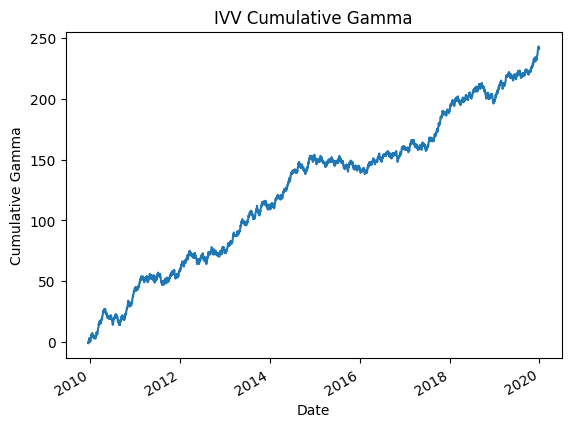

In [45]:
plt.figure()
feat_df["Gamma_t"].cumsum().plot()
plt.title(f"{TICKER} Cumulative Gamma")
plt.xlabel("Date")
plt.ylabel("Cumulative Gamma")
plt.show()

In [46]:
y = feat_df["Gamma"].astype(int)

X = feat_df.drop(columns=["Gamma", "close_prev"])

print("Feature matrix shape:", X.shape)

Feature matrix shape: (2527, 324)


Data Normalization

In [47]:
#Normalize (min-max) 
scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

Feature Selection

In [48]:
corr = X_scaled.corrwith(pd.Series(y, index=X_scaled.index)).abs().sort_values(ascending=False)
print(corr)

CDL_HANGINGMAN          0.054745
ADOSC_3_10              0.042361
BOP                     0.040344
CMF_20                  0.039591
PVOs_12_26_9            0.039245
                          ...   
CDL_RISEFALL3METHODS         NaN
SQZ_NO                       NaN
SQZPRO_NO                    NaN
TMOM_14_5_3                  NaN
TMOMs_14_5_3                 NaN
Length: 324, dtype: float64


In [49]:
corr.head(15)

CDL_HANGINGMAN      0.054745
ADOSC_3_10          0.042361
BOP                 0.040344
CMF_20              0.039591
PVOs_12_26_9        0.039245
CDL_DOJISTAR        0.038215
UO_7_14_28          0.037992
MFI_14              0.036145
EXHC_DNa            0.035185
SQZ_ON              0.034769
SQZPRO_ON_NORMAL    0.034769
SQZ_OFF             0.034769
PVO_12_26_9         0.033622
SQZPRO_ON_WIDE      0.032577
SQZPRO_OFF          0.032577
dtype: float64

Model Training

In [51]:
# MLP
def make_mlp(p, random_state=0):
    hidden = int((p + len(np.unique(y))) / 2)
    return MLPClassifier(
        hidden_layer_sizes=(hidden,),
        activation="logistic",
        solver="lbfgs",
        learning_rate="adaptive",
        learning_rate_init=0.03,
        max_iter=5000,
        momentum=0.2,
        random_state=random_state,
        early_stopping=False
    )

#cross validation function
def cv_accuracy(X_use, y_use, k=10):
    skf = StratifiedKFold(n_splits=k, shuffle=False)
    accs = []
    for fold, (train_idx, test_idx) in enumerate(skf.split(X_use, y_use), start=1):
        X_train, X_test = X_use.iloc[train_idx], X_use.iloc[test_idx]
        y_train, y_test = y_use.iloc[train_idx], y_use.iloc[test_idx]

        clf = make_mlp(p=X_use.shape[1], random_state=0)
        clf.fit(X_train, y_train)
        preds = clf.predict(X_test)
        accs.append(accuracy_score(y_test, preds))
    return np.array(accs)

# Baseline: all features
baseline_accs = cv_accuracy(X_scaled, y, k=10)
baseline_median = np.median(baseline_accs)

Model Evaluation

In [52]:
# Evaluate several "Selected" sizes using correlation top percent

num_grid = [5, 7, 10, 20, 50, 100, 323]  
results = []

for num in num_grid:
    k_feats = max(1, num)
    selected_cols = corr.index[:k_feats]
    X_sel = X_scaled[selected_cols]

    accs = cv_accuracy(X_sel, y, k=10)
    results.append({
        "Ticker": TICKER,
        "Selected_%": num,
        "Num_Features": k_feats,
        "Median_Acc_%": 100 * np.median(accs),
        "Mean_Acc_%": 100 * np.mean(accs),
        "Gain_vs_All_(pp)": 100 * (np.median(accs) - baseline_median)  # percentage points
    })

res_df = pd.DataFrame(results)
print("\n=== Results table (Correlation selection) ===")
print(res_df)


=== Results table (Correlation selection) ===
  Ticker  Selected_%  Num_Features  Median_Acc_%  Mean_Acc_%  Gain_vs_All_(pp)
0    IVV           5             5     54.851308   54.371353          5.839450
1    IVV           7             7     54.851308   54.530240          5.839450
2    IVV          10            10     54.256854   54.093732          5.244997
3    IVV          20            20     54.150198   53.223069          5.138340
4    IVV          50            50     49.007937   49.029425         -0.003921
5    IVV         100           100     50.000000   50.257858          0.988142
6    IVV         323           323     47.919412   47.764759         -1.092446


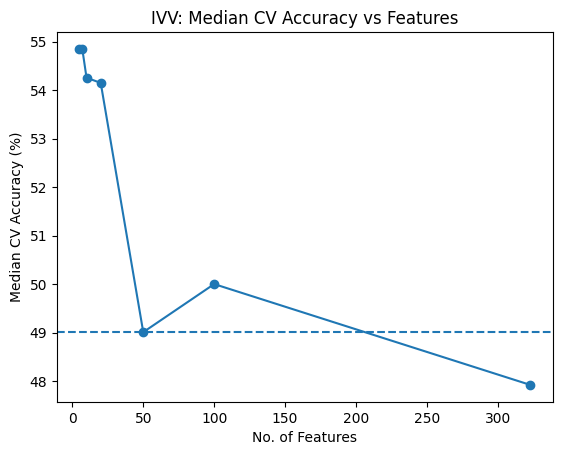

In [54]:
plt.figure()
plt.plot(res_df["Num_Features"], res_df["Median_Acc_%"], marker="o")
plt.axhline(100 * baseline_median, linestyle="--")
plt.title(f"{TICKER}: Median CV Accuracy vs Features")
plt.xlabel("No. of Features")
plt.ylabel("Median CV Accuracy (%)")
plt.show()